# PCB Defect Detection - Evaluation & Export

Loads the already-trained model and artifacts written by **train.ipynb** (`runs/`, `./working/output/`) and does NOT retrain — safe to re-run or restart the kernel any time.

Run `train.ipynb` first if `runs/detect/pcb_m_sota_v8_clean_fixed/` doesn't exist yet.

In [7]:
import os
import glob
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from ultralytics import YOLO

In [8]:
import kagglehub

# Idempotent/cached - just resolves the local dataset path, no retraining involved
root_dir = kagglehub.dataset_download("akhatova/pcb-defects")
dataset_dir = os.path.join(root_dir, 'PCB_DATASET')
images_dir = os.path.join(dataset_dir, 'images')
annot_dir = os.path.join(dataset_dir, 'Annotations')

output_dir = "./working/output"
ksplit = 3

classes = ['missing_hole', 'mouse_bite', 'open_circuit',
           'short', 'spur', 'spurious_copper']

print("Dataset path:", root_dir)
print("Output path:", output_dir)

/home/harshith/Dev/Project/pcb-dd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: /home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1
Output path: ./working/output


In [9]:
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    data = []

    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    for obj in root.findall('object'):
        name = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        data.append({
            'filename': filename,
            'width': width,
            'height': height,
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

    return data


def get_subfolder(image_name):
    if 'missing' in image_name.split('_'):
        return 'Missing_hole'
    if 'mouse' in image_name.split('_'):
        return 'Mouse_bite'
    if 'open' in image_name.split('_'):
        return 'Open_circuit'
    if 'short' in image_name.split('_'):
        return 'Short'
    if 'spur' in image_name.split('_'):
        return 'Spur'
    if 'spurious' in image_name.split('_'):
        return 'Spurious_copper'


def visualize_annotations(image_name, images_dir, annot_df, is_subfolder=False):
    if is_subfolder:
        image_path = os.path.join(
            images_dir, get_subfolder(image_name), image_name)
    else:
        image_path = os.path.join(images_dir, image_name)

    image = cv2.imread(image_path)

    annotations = annot_df[annot_df['filename'] == image_name]

    for _, annot in annotations.iterrows():
        xmin, ymin, xmax, ymax = annot['xmin'], annot['ymin'], annot['xmax'], annot['ymax']
        class_label = annot['class']

        confidence = annot.get('confidence')
        if confidence is not None:
            class_label += f" ({confidence:.2f})"

        color = (255, 255, 255)
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 3)

        text_size = cv2.getTextSize(
            class_label, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 2)[0]
        cv2.rectangle(image, (xmin, ymin - text_size[1] - 5),
                      (xmin + text_size[0], ymin - 1), color, -1)

        cv2.putText(image, class_label, (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 2)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title('Annotations')
    plt.text(10, image_rgb.shape[0] + 100, f'Image: {image_name}',
             color='black', fontsize=11, ha='left')
    plt.show()

    return image

In [10]:
# Re-parse the original XML annotations (fast - not part of training)
all_data = []
for root, dirs, files in os.walk(annot_dir):
    for name in files:
        if name.endswith('.xml'):
            all_data.extend(parse_xml(os.path.join(root, name)))

annot_df = pd.DataFrame(all_data)
annot_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,07_short_05.jpg,2904,1921,short,1896,634,1992,717
1,07_short_05.jpg,2904,1921,short,1418,908,1537,998
2,07_short_05.jpg,2904,1921,short,2184,610,2313,691
3,07_short_05.jpg,2904,1921,short,1453,463,1584,546
4,07_short_05.jpg,2904,1921,short,2113,451,2217,534


In [11]:
# Fold dataset yaml files were written to disk by train.ipynb - reload them
# instead of recomputing the k-fold split.
save_path = Path(output_dir) / f'{ksplit}fold_crossval'
ds_yamls = sorted(save_path.glob('split_*/split_*_dataset.yaml'))
ds_yamls

[PosixPath('working/output/3fold_crossval/split_1/split_1_dataset.yaml'),
 PosixPath('working/output/3fold_crossval/split_2/split_2_dataset.yaml'),
 PosixPath('working/output/3fold_crossval/split_3/split_3_dataset.yaml')]

In [12]:
import pandas as pd

train_dir = "runs/detect/pcb_m_sota_v8_clean_fixed/fold_2"  # or f"{project}/run_m_sota", check the actual save path printed during training
results_csv_path = os.path.join(train_dir, "results.csv")

results_df = pd.read_csv(results_csv_path)
results_df.columns = results_df.columns.str.strip()  # ultralytics CSVs sometimes have leading spaces in headers

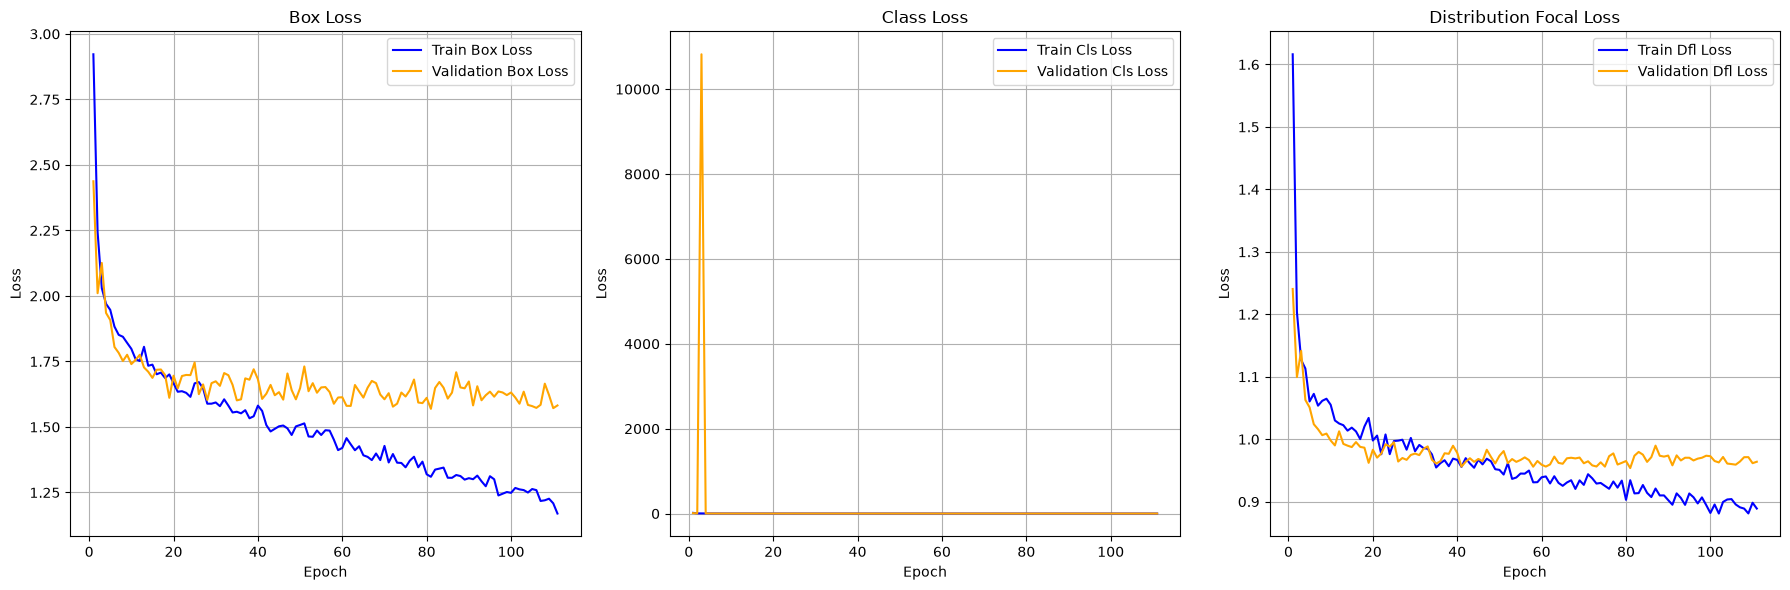

In [13]:
epochs = results_df['epoch']
train_box_loss = results_df['train/box_loss']
val_box_loss = results_df['val/box_loss']
train_cls_loss = results_df['train/cls_loss']
val_cls_loss = results_df['val/cls_loss']
train_dfl_loss = results_df['train/dfl_loss']
val_dfl_loss = results_df['val/dfl_loss']

# Create a figure with three subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot box loss
axs[0].plot(epochs, train_box_loss, label='Train Box Loss', color='blue')
axs[0].plot(epochs, val_box_loss, label='Validation Box Loss', color='orange')
axs[0].set_title('Box Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot cls loss
axs[1].plot(epochs, train_cls_loss, label='Train Cls Loss', color='blue')
axs[1].plot(epochs, val_cls_loss, label='Validation Cls Loss', color='orange')
axs[1].set_title('Class Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Plot dfl loss
axs[2].plot(epochs, train_dfl_loss, label='Train Dfl Loss', color='blue')
axs[2].plot(epochs, val_dfl_loss, label='Validation Dfl Loss', color='orange')
axs[2].set_title('Distribution Focal Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [14]:
# ------------------------------
# Load the trained model
# ------------------------------
train_dir = "runs/detect/pcb_m_sota_v8_clean_fixed/fold_2"
best_model_path = os.path.join(train_dir, "weights/best.pt")
model = YOLO(best_model_path)

print("Using model:", best_model_path)

# ------------------------------
# Run inference on val images
# ------------------------------
test_data_dir = os.path.join(output_dir, "images/val")

metrics = model(source=test_data_dir, imgsz=640, conf=0.25,
                save=True, save_txt=True, save_conf=True)

Using model: runs/detect/pcb_m_sota_v8_clean_fixed/fold_2/weights/best.pt

image 1/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/01_short_06.jpg: 640x640 3 shorts, 26.1ms
image 2/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/01_spur_20.jpg: 640x640 2 spurs, 27.9ms
image 3/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/01_spurious_copper_08.jpg: 640x640 3 spurious_coppers, 27.3ms
image 4/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/04_missing_hole_07.jpg: 640x640 3 missing_holes, 27.0ms
image 5/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/04_missing_hole_10.jpg: 640x640 3 missing_holes, 11.6ms
image 6/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/04_missing_hole_11.jpg: 640x640 3 missing_holes, 27.2ms
image 7/34 /home/harshith/Dev/Project/pcb-dd/working/output/images/val/04_mouse_bite_05.jpg: 640x640 3 mouse_bites, 26.2ms
image 8/34 /home/harshith/Dev/Project/pcb-dd/working/output/imag

In [15]:
# -----------------------------------
# Save predictions safely in working/
# (best.pt lives under train_dir/weights, not inside the
#  prediction output dir, which only contains images/labels)
# -----------------------------------
predict_dir = str(metrics[0].save_dir)
dest_predict_dir = "./working/results/predict2"

os.makedirs(dest_predict_dir, exist_ok=True)

shutil.copytree(predict_dir, dest_predict_dir, dirs_exist_ok=True)

print("✔ Predictions saved to:", dest_predict_dir)

✔ Predictions saved to: ./working/results/predict2


In [16]:
def yolo_to_original_annot(image_name, yolo_labels, annot_df, classes):
    original_annot = []

    for yolo_label in yolo_labels:
        # Extract original width and height from annotation DataFrame
        original_size = annot_df.loc[annot_df['filename']
                                     == image_name, ['width', 'height']].iloc[0]
        original_width, original_height = original_size['width'], original_size['height']

        # Extract YOLO label components
        class_index, x_center, y_center, bbox_width, bbox_height, confidence = yolo_label

        # Scale bounding box coordinates and dimensions to original size
        original_x_center = x_center * original_width
        original_y_center = y_center * original_height
        original_bbox_width = bbox_width * original_width
        original_bbox_height = bbox_height * original_height

        # Calculate original bounding box coordinates
        original_x_min = original_x_center - original_bbox_width / 2
        original_y_min = original_y_center - original_bbox_height / 2
        original_x_max = original_x_center + original_bbox_width / 2
        original_y_max = original_y_center + original_bbox_height / 2

        # Append original annotation to list
        original_annot.append({
            'filename': image_name,
            'width': int(original_width),
            'height': int(original_height),
            'class': classes[int(class_index)],
            'xmin': int(original_x_min),
            'ymin': int(original_y_min),
            'xmax': int(original_x_max),
            'ymax': int(original_y_max),
            'confidence': confidence
        })

    return pd.DataFrame(original_annot)

In [17]:
def read_yolo_labels_from_file(file_path):
    labels = []
    with open(file_path, 'r') as file:
        for line in file:
            values = line.strip().split()
            values = [float(value) for value in values]
            labels.append(values)
    return labels


image_name = '04_missing_hole_10.jpg'
file_path = os.path.join(
    dest_predict_dir, 'labels', os.path.splitext(image_name)[0] + '.txt')
yolo_labels = read_yolo_labels_from_file(file_path)

yolo_labels

[[0.0, 0.429841, 0.133198, 0.02029, 0.0237961, 0.774705],
 [0.0, 0.223727, 0.173704, 0.0215669, 0.0245553, 0.708608],
 [0.0, 0.373813, 0.286822, 0.017695, 0.0188726, 0.681334]]

In [18]:
pred_annot_df = yolo_to_original_annot(
    image_name, yolo_labels, annot_df, classes)
pred_annot_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax,confidence
0,04_missing_hole_10.jpg,3056,2464,missing_hole,1282,298,1344,357,0.774705
1,04_missing_hole_10.jpg,3056,2464,missing_hole,650,397,716,458,0.708608
2,04_missing_hole_10.jpg,3056,2464,missing_hole,1115,683,1169,729,0.681334


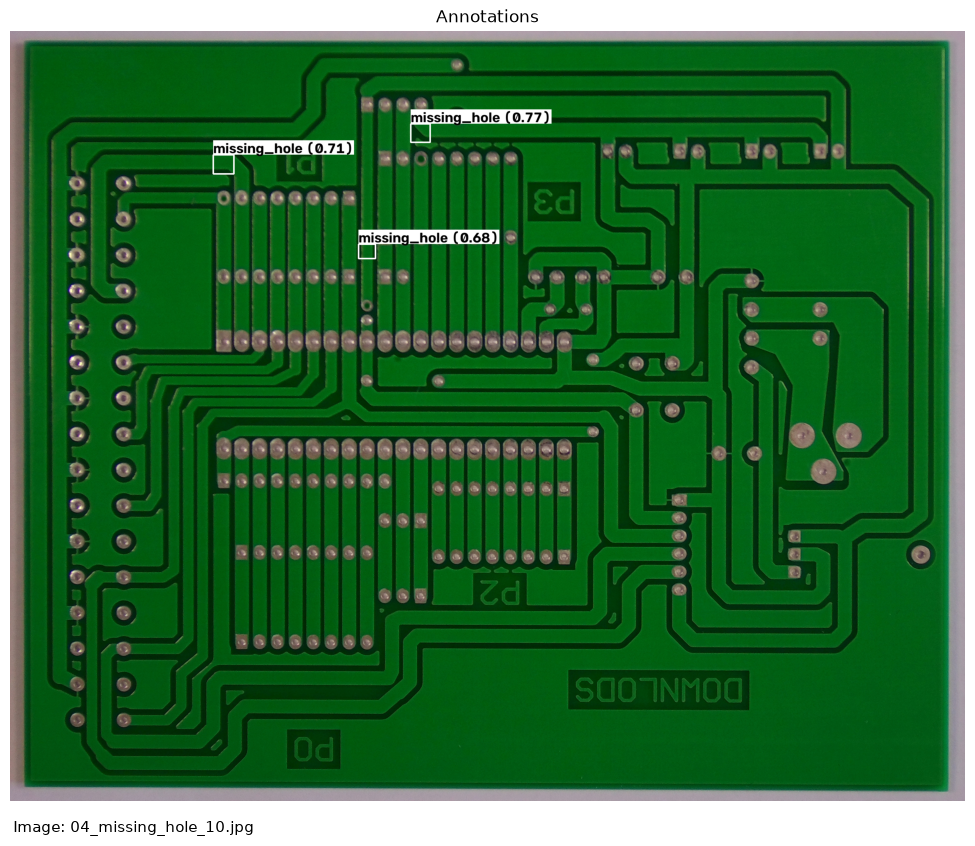

array([[[159, 144, 165],
        [153, 139, 157],
        [155, 142, 158],
        ...,
        [170, 157, 173],
        [168, 155, 171],
        [168, 155, 171]],

       [[154, 139, 160],
        [153, 139, 157],
        [152, 139, 155],
        ...,
        [168, 155, 171],
        [167, 154, 170],
        [169, 156, 172]],

       [[156, 141, 162],
        [159, 145, 163],
        [155, 142, 158],
        ...,
        [166, 153, 169],
        [167, 154, 170],
        [169, 156, 172]],

       ...,

       [[159, 146, 162],
        [159, 146, 162],
        [159, 146, 162],
        ...,
        [161, 151, 164],
        [162, 152, 165],
        [162, 152, 164]],

       [[160, 147, 163],
        [159, 146, 162],
        [158, 145, 161],
        ...,
        [161, 151, 164],
        [161, 151, 164],
        [159, 151, 162]],

       [[163, 150, 166],
        [161, 148, 164],
        [159, 146, 162],
        ...,
        [161, 151, 164],
        [160, 150, 163],
        [158, 150, 161]]

In [19]:
visualize_annotations(image_name, images_dir,
                      pred_annot_df, is_subfolder=True)

## Held-out evaluation and portable export

The three folds were each trained with a different held-out validation split (standard k-fold CV), so the per-epoch `val/*` metrics already logged in `results.csv` are genuine held-out numbers, not train-set leakage. The separate `images/test` split created earlier only ended up with 1 image (train_split=0.95 + val_split=0.05 leaves almost nothing for test), so it isn't usable as an independent test set on its own.

Below: compare the 3 folds, formally re-run `.val()` on the best fold's held-out split, then export a clean, self-contained bundle (`.pt` + `.onnx` + class names + a standalone inference script) that another machine can use without any of the training code above.

In [20]:
import glob

fold_dirs = sorted(glob.glob("runs/detect/pcb_m_sota_v8_clean_fixed/fold_*"))
fold_scores = {}
for fd in fold_dirs:
    df = pd.read_csv(os.path.join(fd, "results.csv"))
    df.columns = df.columns.str.strip()
    fold_scores[fd] = df["metrics/mAP50(B)"].iloc[-1]

for fd, score in fold_scores.items():
    print(f"{fd}: mAP50={score:.4f}")

best_fold_dir = max(fold_scores, key=fold_scores.get)
best_fold_index = fold_dirs.index(best_fold_dir)
print("\nBest fold:", best_fold_dir)

runs/detect/pcb_m_sota_v8_clean_fixed/fold_0: mAP50=0.9465
runs/detect/pcb_m_sota_v8_clean_fixed/fold_1: mAP50=0.9638
runs/detect/pcb_m_sota_v8_clean_fixed/fold_2: mAP50=0.9531

Best fold: runs/detect/pcb_m_sota_v8_clean_fixed/fold_1


In [21]:
# Formal held-out evaluation: re-run YOLO's own .val() pipeline (confusion
# matrix, per-class PR curves, etc.) against the best fold's val split, which
# that fold's training never saw.
eval_model = YOLO(os.path.join(best_fold_dir, "weights", "best.pt"))
val_metrics = eval_model.val(data=str(ds_yamls[best_fold_index]), split="val")

print("Precision:", val_metrics.box.mp)
print("Recall:", val_metrics.box.mr)
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)

Ultralytics 8.4.121 🚀 Python-3.11.16 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 4000 Blackwell Generation Laptop GPU, 16303MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 194.2±129.1 MB/s, size: 185.3 KB)
val: Scanning /home/harshith/Dev/Project/pcb-dd/working/output/3fold_crossval/split_2/val/labels.cache... 219 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 219/219 57.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.7it/s 5.3s0.4s
                   all        219        959      0.962      0.932      0.964      0.505
          missing_hole         38        165      0.978      0.988       0.98      0.572
            mouse_bite         40        179      0.938      0.911      0.961      0.501
          open_circuit         36        155      0.973      0.955      0.982      0.499
                 short         34  

In [22]:
# -----------------------------------------------------------------
# Build a clean, portable deploy bundle: everything another machine
# needs to run inference, and nothing it doesn't (no dataset, no
# training checkpoints from other epochs, no cross-val scaffolding).
# -----------------------------------------------------------------
export_dir = "./working/deploy"
os.makedirs(export_dir, exist_ok=True)

best_weights = os.path.join(best_fold_dir, "weights", "best.pt")
deploy_model = YOLO(best_weights)

# ONNX: portable, runs with just `onnxruntime` — no torch/ultralytics
# needed on the target machine if you use it directly.
onnx_path = deploy_model.export(format="onnx", imgsz=640, simplify=True)

shutil.copy(best_weights, os.path.join(export_dir, "best.pt"))
shutil.copy(onnx_path, os.path.join(export_dir, "best.onnx"))

with open(os.path.join(export_dir, "classes.txt"), "w") as f:
    f.write("\n".join(classes))

print("Deploy bundle ready at:", export_dir)
print(os.listdir(export_dir))

Ultralytics 8.4.121 🚀 Python-3.11.16 torch-2.11.0+cu128 CPU (Intel Core Ultra 9 285HX)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs/detect/pcb_m_sota_v8_clean_fixed/fold_1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (49.7 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.8s, saved as 'runs/detect/pcb_m_sota_v8_clean_fixed/fold_1/weights/best.onnx' (98.8 MB)

Export complete (2.3s)
Results saved to /home/harshith/Dev/Project/pcb-dd/runs/detect/pcb_m_sota_v8_clean_fixed/fold_1/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/pcb_m_sota_v8_clean_fixed/fold_1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/pcb_m_sota_v8_clean_fixed/fold_1/weights/best.onnx imgsz=640 data=working/output/3fold_crossval/split_2/split_2_dataset.yaml  
Visualize:    

In [23]:
predict_script = '''"""
Standalone PCB defect detector inference.
On the target machine: pip install ultralytics onnxruntime
(ultralytics loads either best.pt or best.onnx and handles
pre/post-processing + NMS for you - no training code needed.)

Runs on CPU by default so it works on any machine regardless of
GPU/CUDA setup. If the target machine has a matching CUDA + cuDNN
install, change DEVICE below to 0 for GPU inference.

Usage: python predict.py path/to/image.jpg
"""
import sys
from ultralytics import YOLO

MODEL_PATH = "best.onnx"  # or "best.pt"
DEVICE = "cpu"


def main(image_path):
    model = YOLO(MODEL_PATH, task="detect")
    results = model(image_path, conf=0.25, device=DEVICE)
    for r in results:
        r.save(filename="prediction.jpg")
        for box in r.boxes:
            cls_name = model.names[int(box.cls)]
            conf = float(box.conf)
            print(f"{cls_name}: {conf:.2f}")
    print("Annotated image saved to prediction.jpg")


if __name__ == "__main__":
    main(sys.argv[1])
'''

with open(os.path.join(export_dir, "predict.py"), "w") as f:
    f.write(predict_script)

readme = f'''PCB Defect Detector - deploy bundle
====================================

Files:
  best.pt      - native ultralytics/PyTorch weights
  best.onnx    - portable ONNX export (use this unless you need .pt specifically)
  classes.txt  - class names, in label-index order
  predict.py   - minimal standalone inference script (CPU by default)

Setup on the new machine:
  pip install ultralytics onnxruntime
  python predict.py your_image.jpg

Classes: {", ".join(classes)}
'''

with open(os.path.join(export_dir, "README.txt"), "w") as f:
    f.write(readme)

print("Wrote predict.py and README.txt to", export_dir)

Wrote predict.py and README.txt to ./working/deploy


In [26]:
from IPython.display import FileLink

zip_base = "pcb_defect_model"
shutil.make_archive(zip_base, "zip", export_dir)

zip_path = f"{zip_base}.zip"
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"✔ {zip_path} created ({size_mb:.2f} MB)")
print("Copy this single file to the other machine, unzip it, and follow README.txt")
display(FileLink(zip_path))

✔ pcb_defect_model.zip created (127.99 MB)
Copy this single file to the other machine, unzip it, and follow README.txt


/home/harshith/Dev/Project/pcb-dd/pcb_defect_model.zip